In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Load data
url = "https://raw.githubusercontent.com/diplomadoequipo908-a11y/Proyecto-modulo-5/main/dataset.csv"
raw = pd.read_csv(url)
raw = raw.drop(columns=['Unnamed: 0'])
# Drop duplicates on track_id keep unique tracks.
df = raw.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
print('Raw data:',raw.shape)
print('Unique tracks data:',df.shape)
df.describe()

Raw data: (114000, 20)
Unique tracks data: (89741, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Data Dictionary
| Column | Type | Range | Description |
|---|---|---|---|
| `track_id` | String | — | Unique Spotify URI identifier for the track |
| `artists` | String | — | Performing artist name(s) |
| `album_name` | String | — | Album the track belongs to |
| `track_name` | String | — | Title of the track |
| `popularity` | Integer | 0 – 100 | Spotify popularity score (higher = more popular) |
| `duration_ms` | Integer | 0 – 5.2M | Track duration in milliseconds |
| `explicit` | Boolean | True/False | Whether the track has explicit lyrics |
| `danceability` | Float | 0.0 – 1.0 | How suitable a track is for dancing |
| `energy` | Float | 0.0 – 1.0 | Perceptual measure of intensity and activity |
| `key` | Integer | 0 – 11 | Musical key (0=C, 1=C♯, 2=D … 11=B) |
| `loudness` | Float | -49.5 – 4.5 | Overall loudness in decibels (dB) |
| `mode` | Integer | 0 or 1 | Modality — 1 = Major, 0 = Minor |
| `speechiness` | Float | 0.0 – 1.0 | Presence of spoken words in the track |
| `acousticness` | Float | 0.0 – 1.0 | Confidence the track is acoustic |
| `instrumentalness` | Float | 0.0 – 1.0 | Predicts whether a track has no vocals |
| `liveness` | Float | 0.0 – 1.0 | Detects presence of a live audience |
| `valence` | Float | 0.0 – 1.0 | Musical positiveness conveyed by the track |
| `tempo` | Float | 0 – 243 | Estimated tempo in beats per minute (BPM) |
| `time_signature` | Integer | 0 – 5 | Estimated time signature of the track |
| `track_genre` | String | 114 classes | Genre label assigned to the track |

## Null values

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [4]:
# Fill null values
for col in ['track_name', 'album_name', 'artists']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


# Exploratory Data Analysis
## Popularity distribution

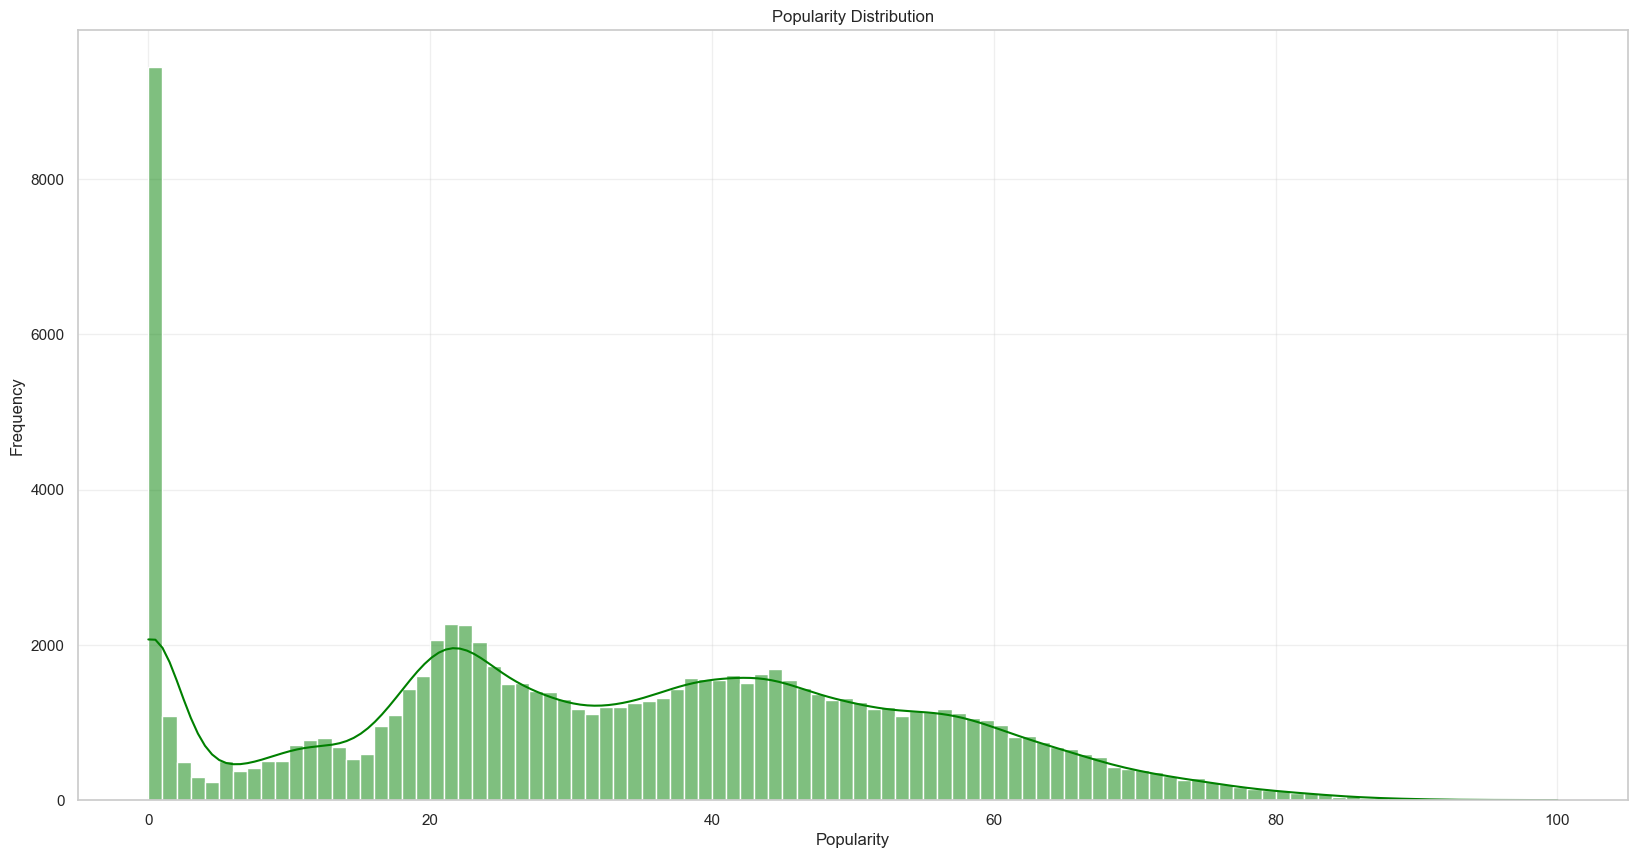

In [5]:
plt.figure(figsize=(20,10))
sns.histplot(df['popularity'], bins=100, kde=True,color='green')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [6]:
print(f"Mean: {df['popularity'].mean():.2f}")
print(f"Median: {df['popularity'].median():.2f}")
print(f"Skewness: {skew(df['popularity']):.3f}")

Mean: 33.20
Median: 33.00
Skewness: 0.071


##### Popularity is approximately symmetric and not dominated by extreme values

#### Popular vs unpopular songs

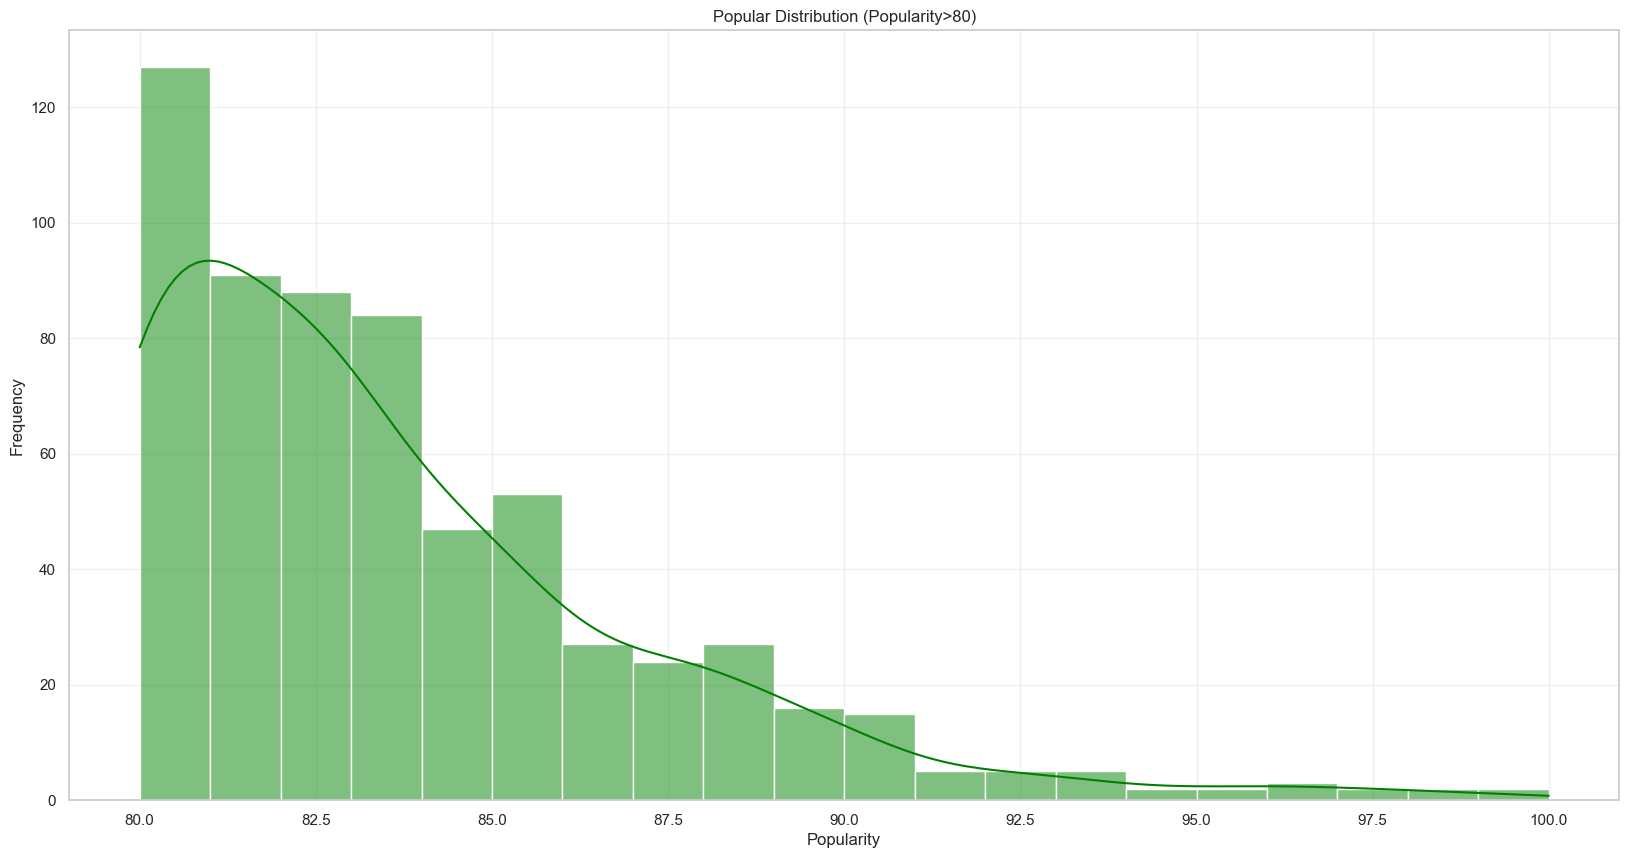

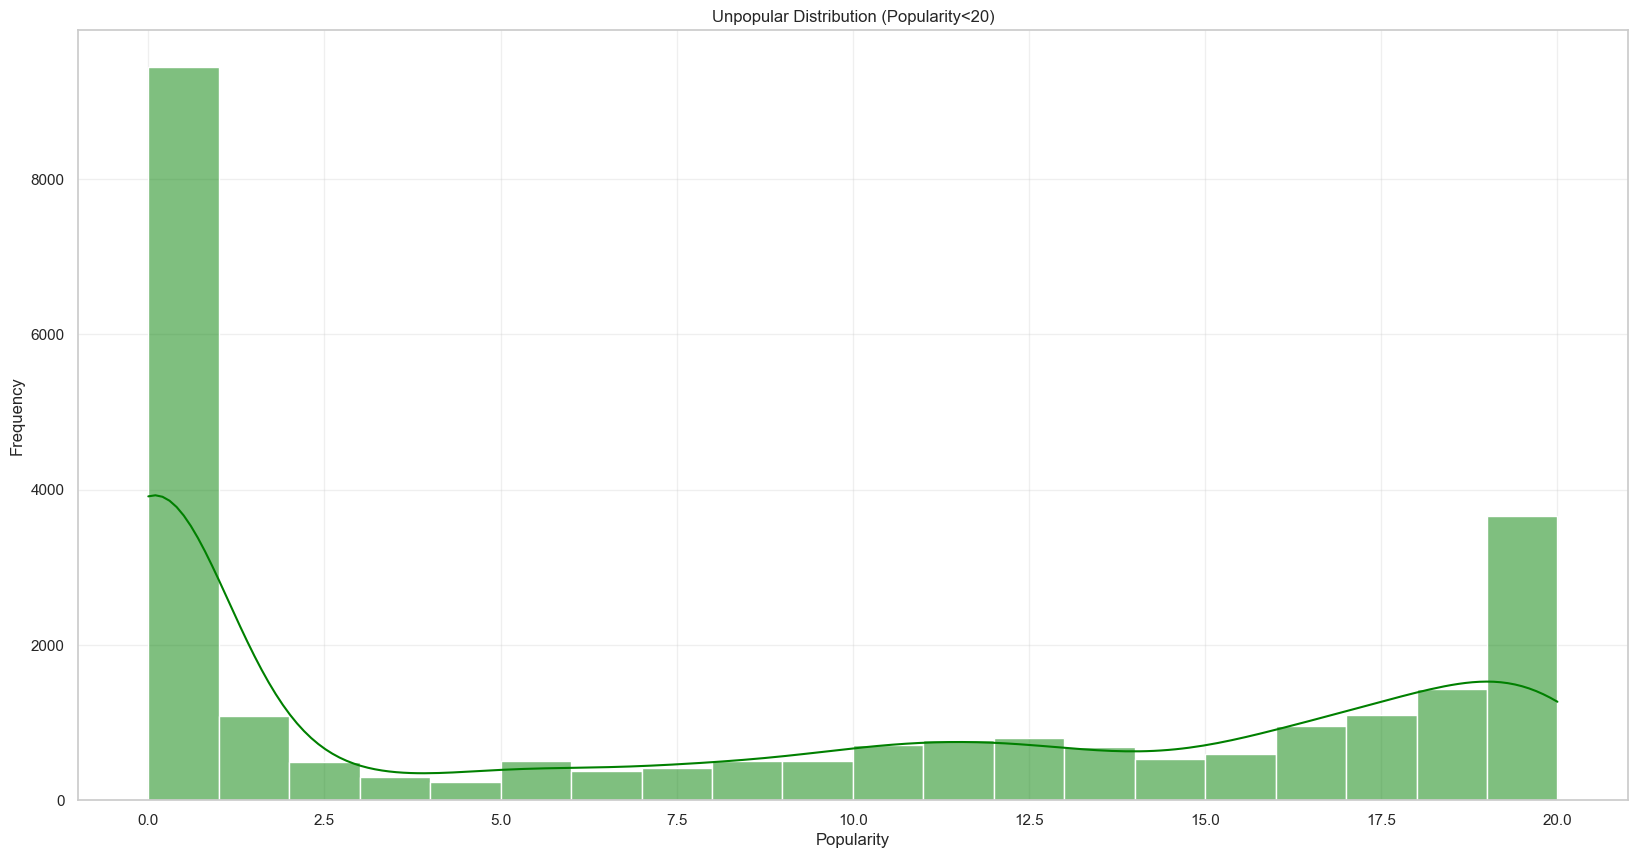

In [7]:
popular = df[df['popularity'] >= 80]

unpopular = df[df['popularity'] <= 20]

plt.figure(figsize=(20,10))
sns.histplot(popular['popularity'], bins=20, kde=True,color='green')
plt.title('Popular Distribution (Popularity>80)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,10))
sns.histplot(unpopular['popularity'], bins=20, kde=True,color='green')
plt.title('Unpopular Distribution (Popularity<20)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

## Top 20 genres

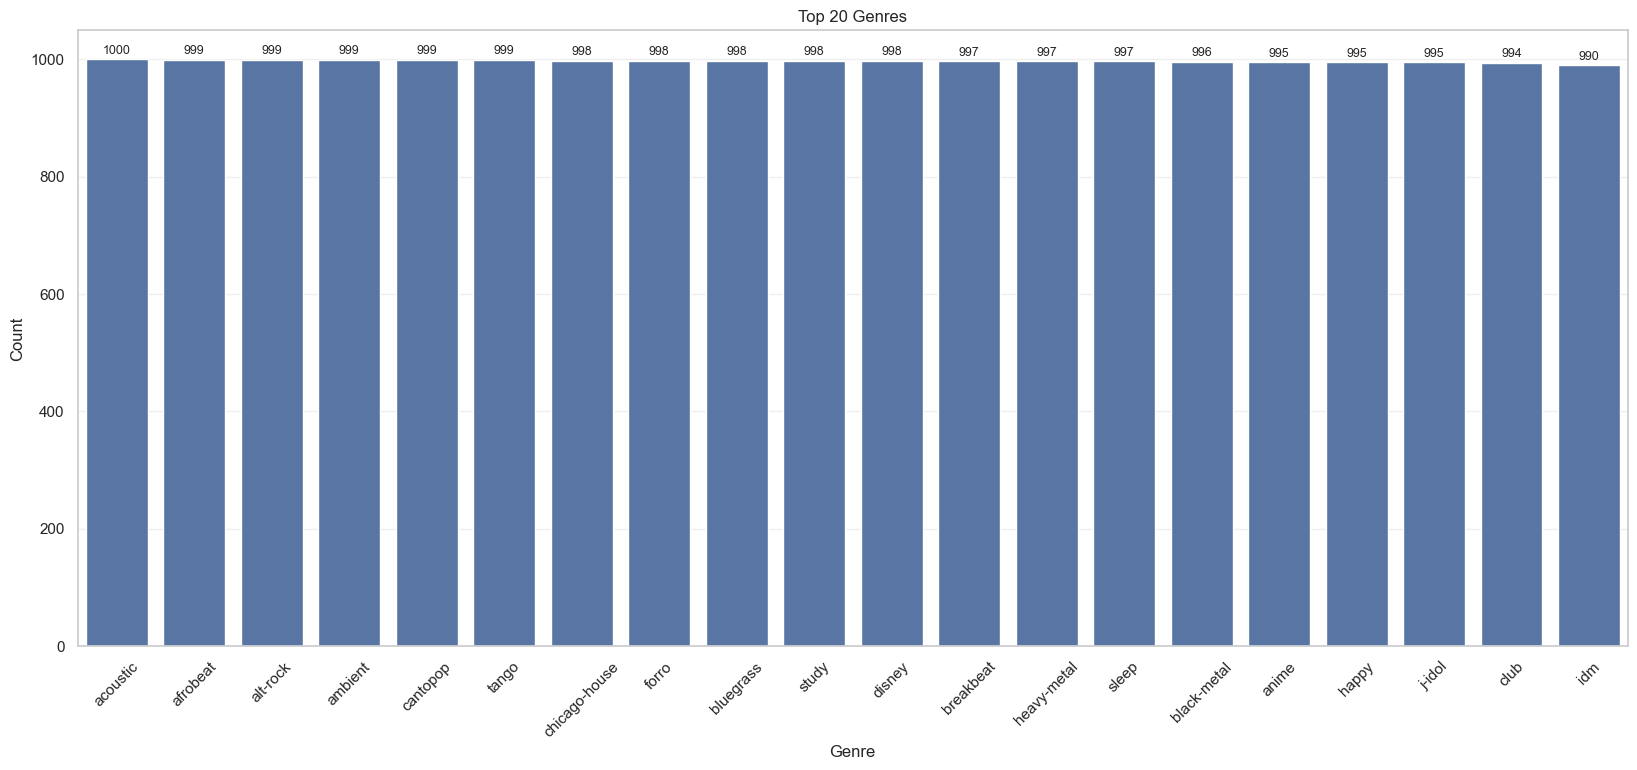

In [8]:
plt.figure(figsize=(20,8))
top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
)
ax = sns.barplot(x=top_genres.index,y=top_genres.values)

for i, v in enumerate(top_genres.values):
    ax.text(
        i,
        v + 10,
        str(v),
        ha='center',
        fontsize=9
    )

plt.title("Top 20 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Average popularity by genres

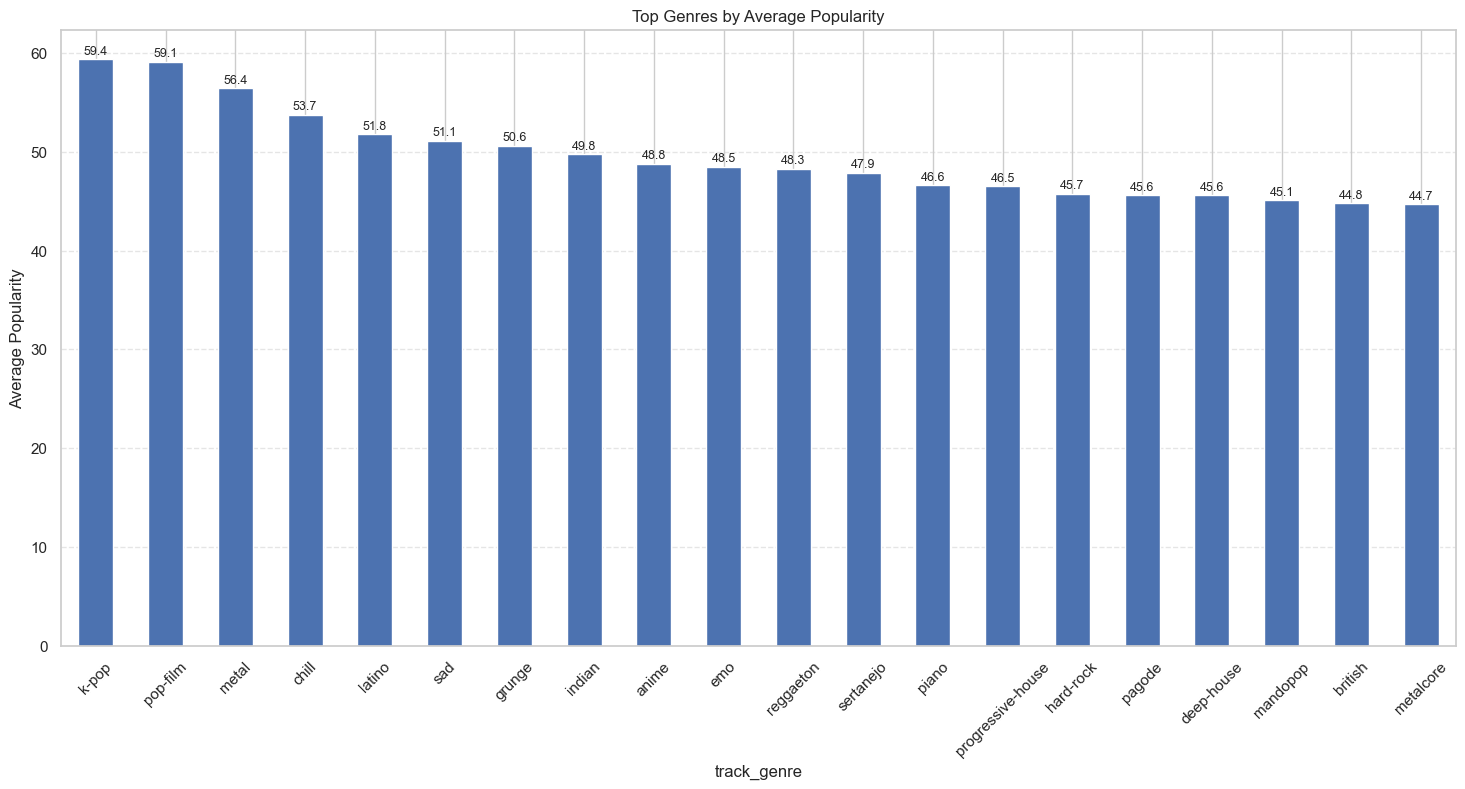

In [9]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)

top_20 = genre_popularity.head(20)

plt.figure(figsize=(18,8))
ax = top_20.plot(kind='bar')
for i, v in enumerate(top_20.values):
    ax.text(
        i,
        v + 0.5,
        f'{v:.1f}',
        ha='center',
        fontsize=9
    )
plt.title("Top Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)
plt.show()

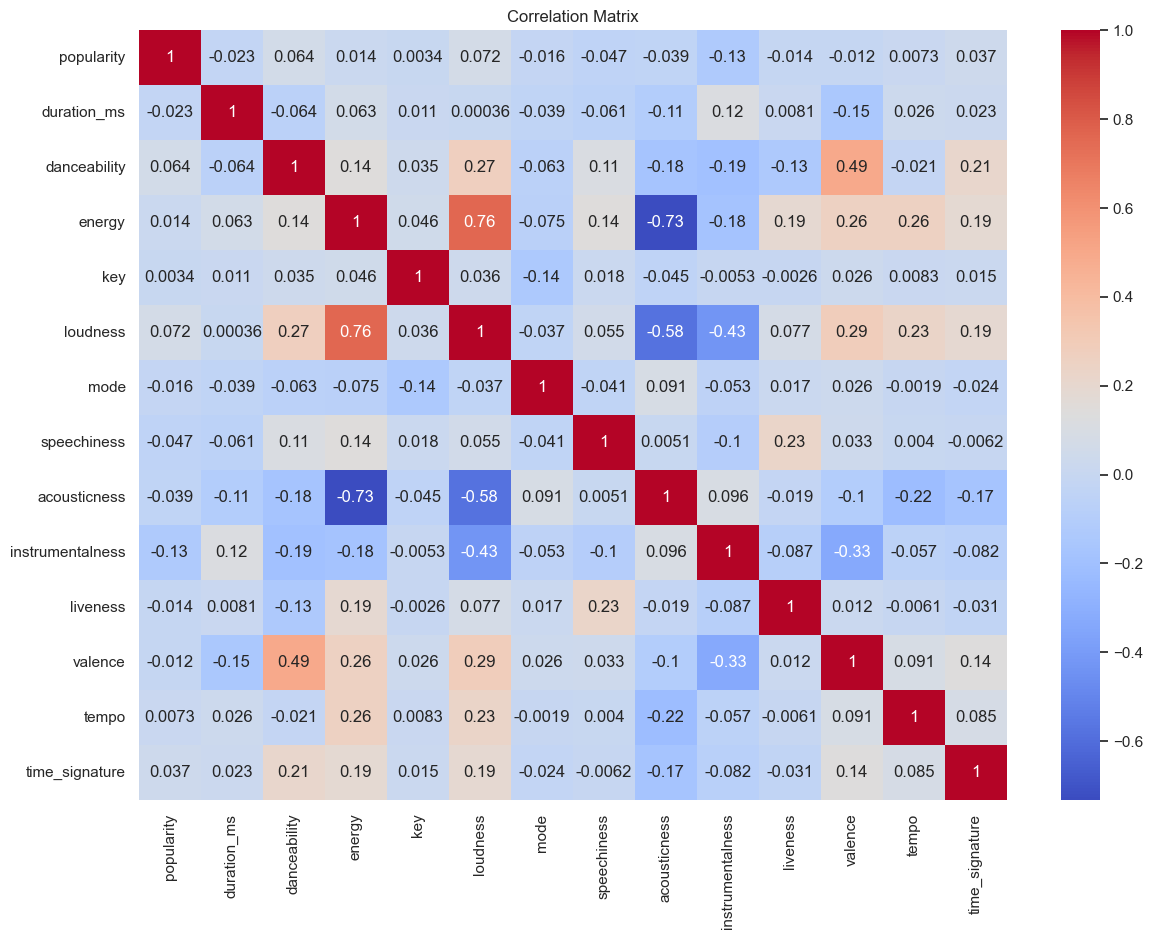

In [10]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

## Correlation with Popularity (Linear)

loudness            0.071676
danceability        0.064281
time_signature      0.036893
energy              0.013728
tempo               0.007270
key                 0.003432
valence            -0.011526
liveness           -0.013844
mode               -0.016214
duration_ms        -0.023119
acousticness       -0.038847
speechiness        -0.047081
instrumentalness   -0.127465
Name: popularity, dtype: float64


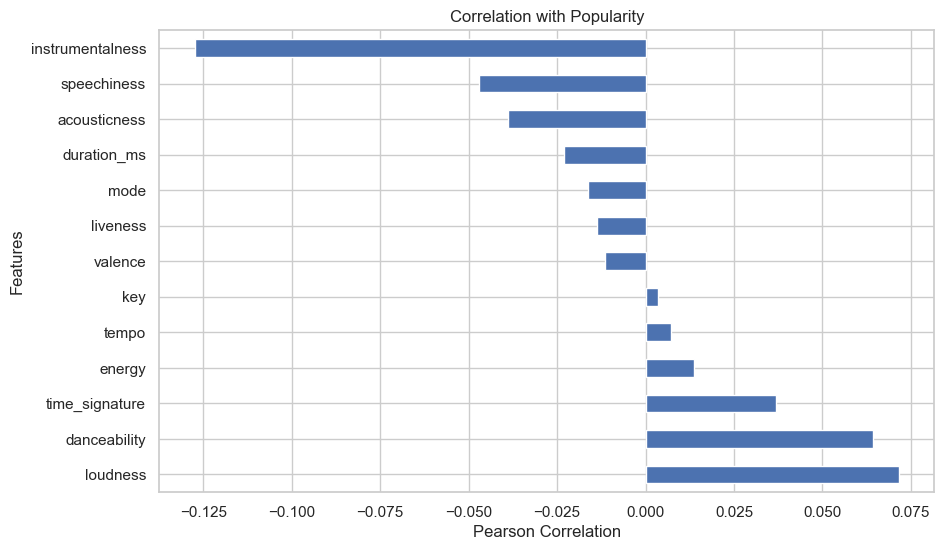

In [11]:
corr_popularity = (
    df.select_dtypes(include=np.number)
      .corr()['popularity']
      .drop('popularity')
      .sort_values(ascending=False)
)

print(corr_popularity)

plt.figure(figsize=(10,6))
corr_popularity.plot(kind='barh')
plt.title("Correlation with Popularity")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.show()

##### We can observe that there are no linear audio characteristics correlations with popularity. These findings suggest that popularity is likely driven by complex interactions among multiple audio characteristics and genre-specific effects. Consequently, a nonlinear modeling approach such as a Multilayer Perceptron (MLP) may be better suited to capture these relationships than traditional linear models.

In [12]:
#df['is_niche'] = (df['popularity'] <= 20)

# counts = df['is_niche'].value_counts()

# labels = [
#     'Non-Niche Songs',
#     'Niche Songs'
# ]

# plt.figure(figsize=(8,8))

# plt.pie(
#     counts.values,
#     labels=labels,
#     autopct='%1.1f%%',
#     startangle=90
# )

# plt.title(
#     "Distribution of Niche vs Non-Niche Songs",
#     fontsize=16,
#     fontweight='bold'
# )

# plt.show()


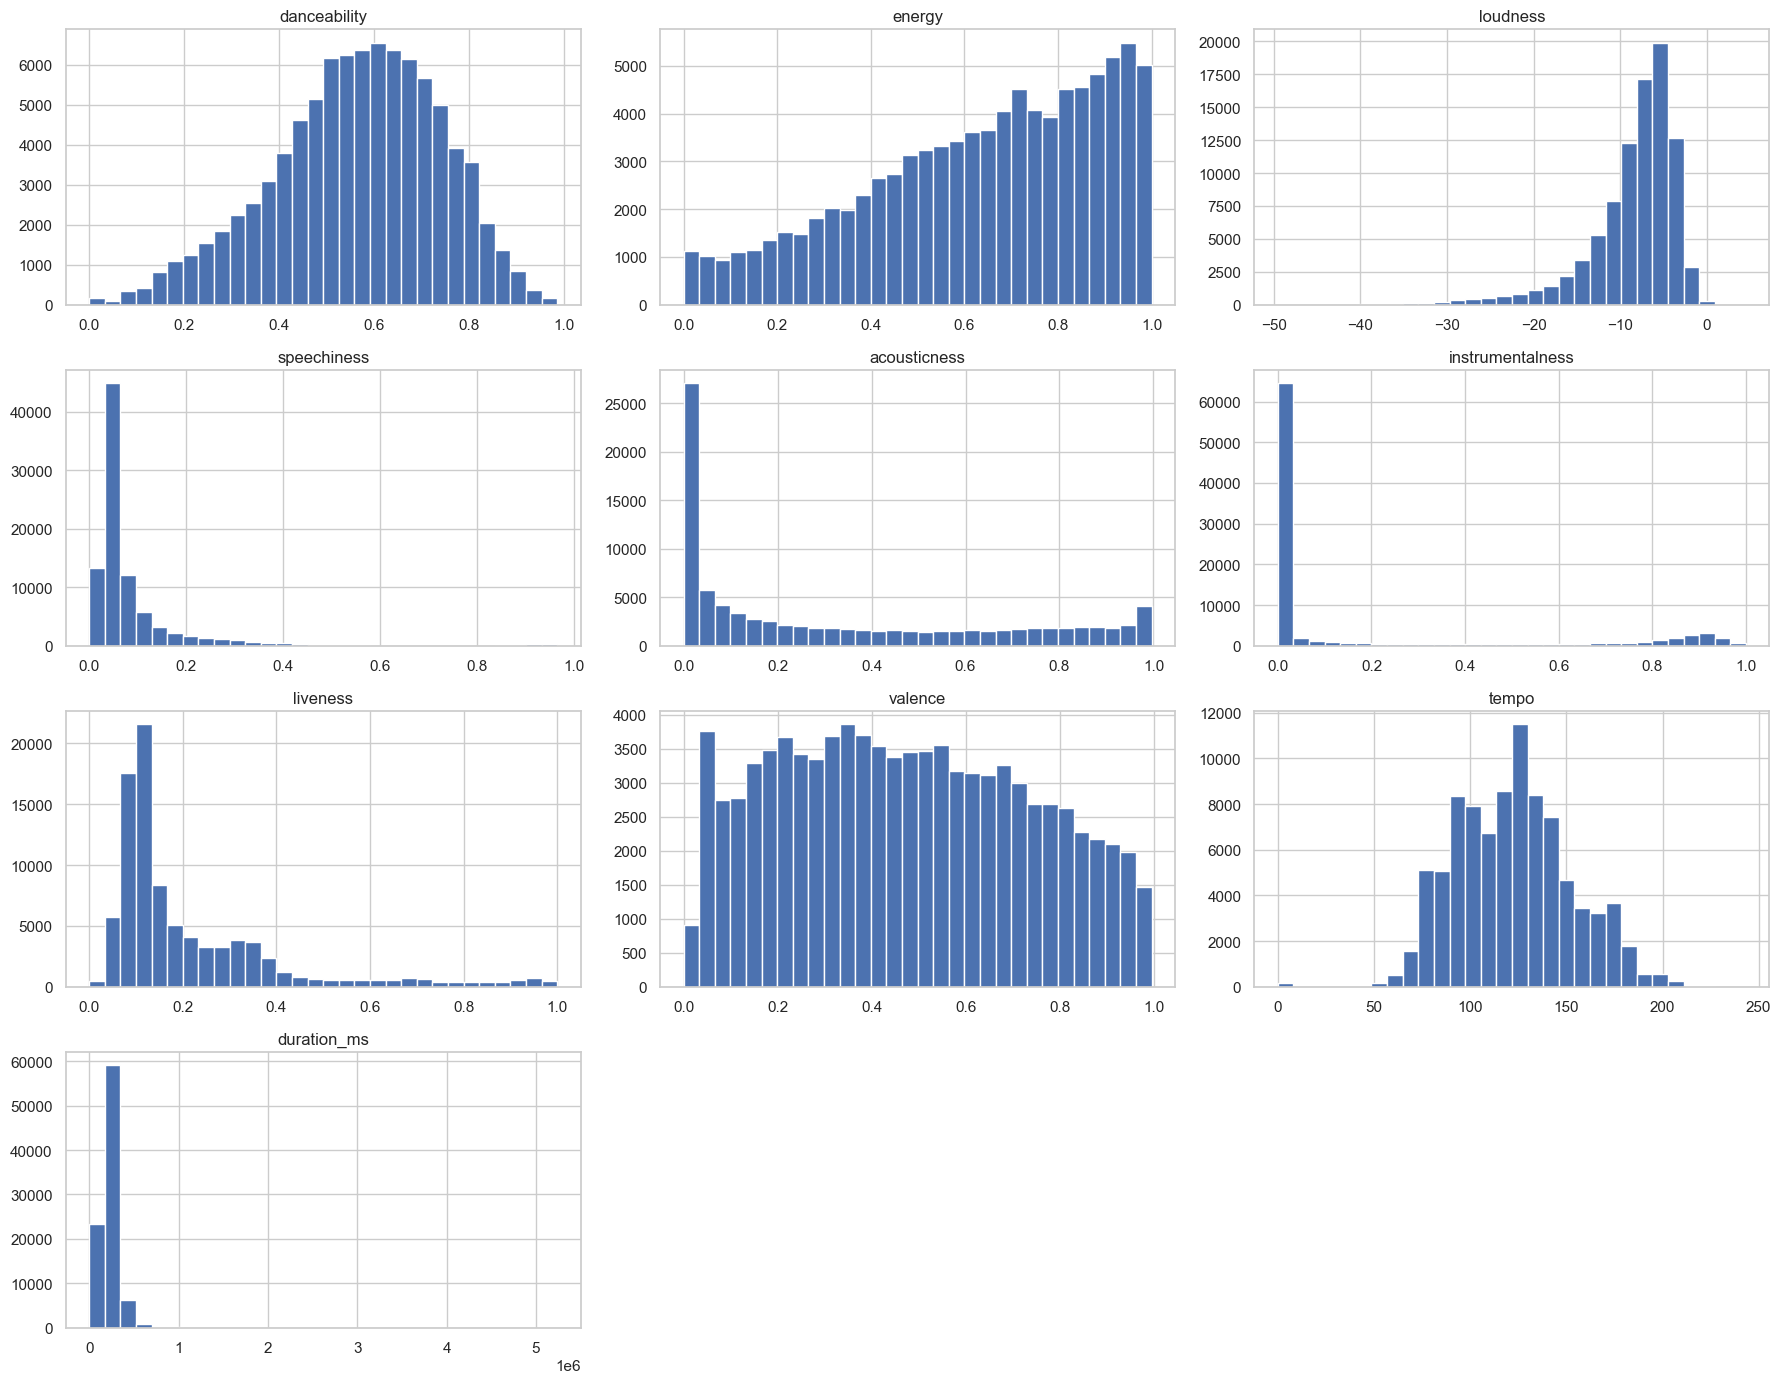

In [13]:
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

df[numeric_features].hist(
    bins=30,
    figsize=(18,14)
)

plt.tight_layout()

plt.show()

## Linear and Quantile regression

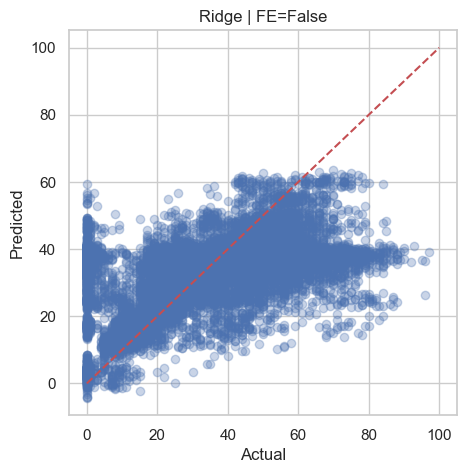

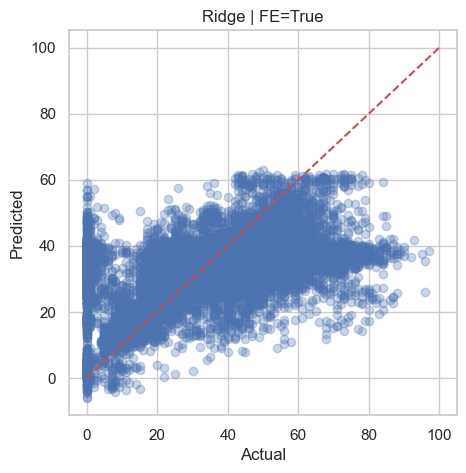

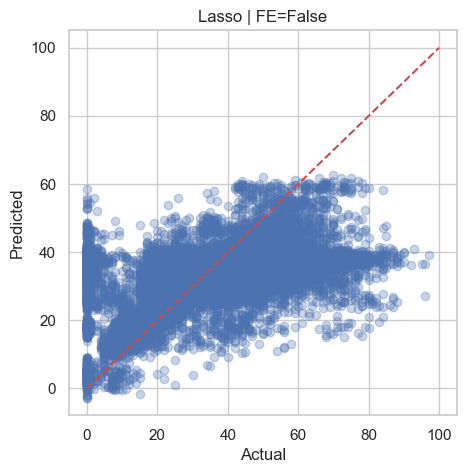

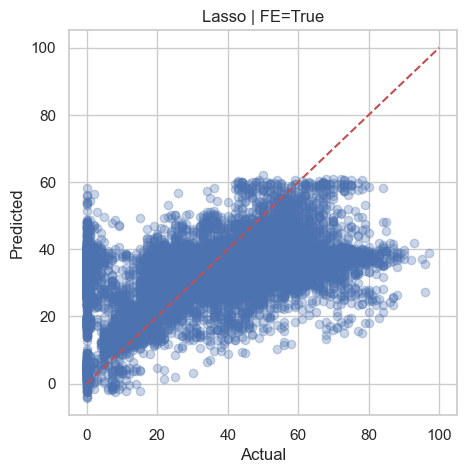

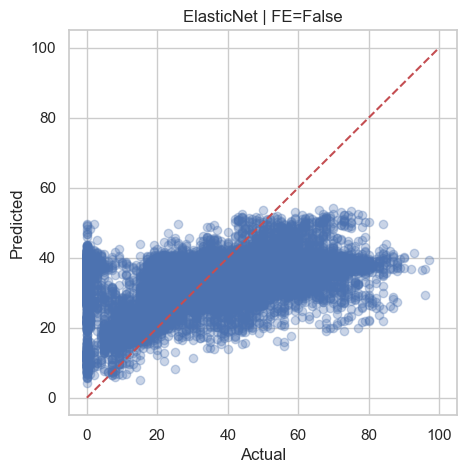

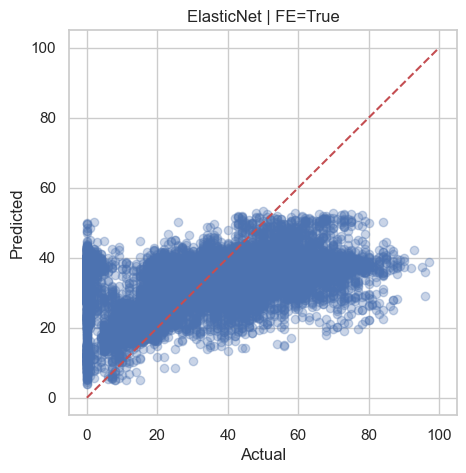


=== MODEL COMPARISON ===
        Model  Feature_Engineering    MAE_val    R2_val   MAE_test   R2_test
1       Ridge                 True  13.589767  0.221204  13.558261  0.218749
0       Ridge                False  13.604066  0.218811  13.561289  0.217288
3       Lasso                 True  13.674936  0.220088  13.644495  0.217973
2       Lasso                False  13.694243  0.217806  13.657599  0.216135
5  ElasticNet                 True  14.190941  0.202752  14.180542  0.199766
4  ElasticNet                False  14.216702  0.200437  14.203638  0.198030


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df_lr = df.drop(columns=[
    'track_id',
    'track_name',
    'album_name',
    'artists',
    'time_signature'
])

df_lr['explicit'] = df_lr['explicit'].astype(int)
df_lr['key'] = df_lr['key'].astype(str)

# Log transform (skewed)
df_lr['duration_ms'] = np.log1p(df_lr['duration_ms'])

# Feature engineering
def add_features(df):
    df = df.copy()

    # Interactions
    df['energy_dance'] = df['energy'] * df['danceability']
    df['valence_energy'] = df['valence'] * df['energy']
    df['acoustic_valence'] = df['acousticness'] * df['valence']

    # Non-linear
    df['tempo_squared'] = df['tempo'] ** 2

    # Domain features
    df['is_live'] = (df['liveness'] > 0.8).astype(int)
    df['is_instrumental'] = (df['instrumentalness'] > 0.7).astype(int)
    df['is_happy'] = (df['valence'] > 0.7).astype(int)

    return df

# Features/Target
X = df_lr.drop(columns='popularity')
y = df_lr['popularity']

num_features = [
    'duration_ms', 'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

engineered_features = [
    'energy_dance', 'valence_energy', 'acoustic_valence',
    'tempo_squared', 'is_live', 'is_instrumental', 'is_happy'
]

cat_features = ['key', 'track_genre']

# Train/Test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Model evaluation function
def run_model(model, use_engineering=False):

    if use_engineering:
        X_train_mod = add_features(X_train)
        X_val_mod = add_features(X_val)
        X_test_mod = add_features(X_test)
        current_num = num_features + engineered_features
    else:
        X_train_mod = X_train.copy()
        X_val_mod = X_val.copy()
        X_test_mod = X_test.copy()
        current_num = num_features

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), current_num),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            min_frequency=0.01
        ), cat_features)
    ])

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    # Train
    pipe.fit(X_train_mod, y_train)

    # Validation predictions
    val_preds = pipe.predict(X_val_mod)
    test_preds = pipe.predict(X_test_mod)

    # Metrics
    results = {
        'MAE_val': mean_absolute_error(y_val, val_preds),
        'RMSE_val': np.sqrt(mean_squared_error(y_val, val_preds)),
        'R2_val': r2_score(y_val, val_preds),
        'MAE_test': mean_absolute_error(y_test, test_preds),
        'R2_test': r2_score(y_test, test_preds)
    }

    # Plot
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, test_preds, alpha=0.3)
    plt.plot([0,100], [0,100], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{model.__class__.__name__} | FE={use_engineering}')
    plt.show()

    return results

# Models 
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)
}

# Run
all_results = []

for name, model in models.items():

    # Without feature engineering
    res_base = run_model(model, use_engineering=False)
    res_base['Model'] = name
    res_base['Feature_Engineering'] = False

    # With feature engineering
    res_fe = run_model(model, use_engineering=True)
    res_fe['Model'] = name
    res_fe['Feature_Engineering'] = True

    all_results.append(res_base)
    all_results.append(res_fe)

# Results comparisson
results_df = pd.DataFrame(all_results)

results_df = results_df[[
    'Model',
    'Feature_Engineering',
    'MAE_val',
    'R2_val',
    'MAE_test',
    'R2_test'
]]

print("\n=== MODEL COMPARISON ===")
print(results_df.sort_values('MAE_val'))

##### From the analysis, acoustic features alone have limited ability to explain song popularity. The correlation matrix shows that all relationships between individual features and popularity are very weak, which indicates that popularity is not driven by any single measurable audio characteristic. 
##### Across the models tested, Ridge regression consistently performed slightly better than Lasso and ElasticNet. This outcome aligns with the structure of the data, where many features are strongly correlated with each other. Ridge handles this multicollinearity more effectively by distributing importance across correlated variables, rather than eliminating them as Lasso does. ElasticNet, which combines both approaches, did not provide additional benefit in this case.
##### Feature engineering, including interaction terms and nonlinear transformations, resulted in only marginal improvements. This suggests that the limitation is not the absence of simple transformations, but rather that the relationship between the inputs and the target is inherently complex. Linear models, even when enhanced, are reaching their performance limit on this dataset.
##### The overall performance, with an R² of around 0.22, indicates that a large portion of the variability in popularity remains unexplained. This is expected, as popularity is influenced by many external factors that are not present in the dataset, such as artist recognition, marketing, timing, and exposure.
##### At this stage, further tuning of linear models or additional feature engineering is unlikely to produce meaningful improvements. The results indicate that the problem is not under-optimized, but under-modeled. The next logical step is to move toward more flexible nonlinear models, such as gradient boosting or neural networks, which are better suited to capture complex interactions and patterns in this type of data.

### XGBoost

In [16]:
import pandas as pd,numpy as np,matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.model_selection import RandomizedSearchCV

def add_features(df):
    df=df.copy()
    df['energy_dance']=df['energy']*df['danceability']
    df['valence_energy']=df['valence']*df['energy']
    df['acoustic_valence']=df['acousticness']*df['valence']
    df['tempo_squared']=df['tempo']**2
    df['is_live']=(df['liveness']>0.8).astype(int)
    df['is_instrumental']=(df['instrumentalness']>0.7).astype(int)
    df['is_happy']=(df['valence']>0.7).astype(int)
    return df

def run_xgb_tuned(X_train,X_val,X_test,y_train,y_val,y_test,num_features,engineered_features,cat_features,use_engineering=False):
    if use_engineering:
        X_train_mod=add_features(X_train);X_val_mod=add_features(X_val);X_test_mod=add_features(X_test)
    else:
        X_train_mod=X_train.copy();X_val_mod=X_val.copy();X_test_mod=X_test.copy()

    preprocessor=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore',min_frequency=0.01),cat_features)],remainder='passthrough')

    model=XGBRegressor(random_state=42,n_jobs=-1,verbosity=0)

    pipe=Pipeline([('prep',preprocessor),('model',model)])

    param_dist={
        'model__n_estimators':[300,400,500,600,700],
        'model__max_depth':[3,4,5,6],
        'model__learning_rate':[0.01,0.03,0.05,0.07],
        'model__subsample':[0.7,0.8,0.9],
        'model__colsample_bytree':[0.7,0.8,0.9],
        'model__reg_lambda':[0,0.5,1,2],
        'model__reg_alpha':[0,0.1,0.5]
    }

    search=RandomizedSearchCV(pipe,param_distributions=param_dist,n_iter=25,scoring='neg_mean_absolute_error',cv=3,verbose=1,n_jobs=-1,random_state=42)

    search.fit(X_train_mod,y_train)

    best_pipe=search.best_estimator_
    print("\nBest Parameters:",search.best_params_)

    val_preds=best_pipe.predict(X_val_mod)
    test_preds=best_pipe.predict(X_test_mod)

    print(f"\nXGBoost Tuned | FE={use_engineering}")
    print("MAE_val:",mean_absolute_error(y_val,val_preds))
    print("R2_val:",r2_score(y_val,val_preds))
    print("MAE_test:",mean_absolute_error(y_test,test_preds))
    print("R2_test:",r2_score(y_test,test_preds))

    return {
        'Model':'XGBoost Tuned',
        'Feature_Engineering':use_engineering,
        'MAE_val':mean_absolute_error(y_val,val_preds),
        'R2_val':r2_score(y_val,val_preds),
        'MAE_test':mean_absolute_error(y_test,test_preds),
        'R2_test':r2_score(y_test,test_preds)
    }


res_fe = run_xgb_tuned(
    X_train,X_val,X_test,
    y_train,y_val,y_test,
    num_features,engineered_features,cat_features,
    True
)

res_no_fe = run_xgb_tuned(
    X_train,X_val,X_test,
    y_train,y_val,y_test,
    num_features,engineered_features,cat_features,
    False
)


Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Parameters: {'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__max_depth': 6, 'model__learning_rate': 0.07, 'model__colsample_bytree': 0.8}

XGBoost Tuned | FE=True
MAE_val: 12.172490119934082
R2_val: 0.34913718700408936
MAE_test: 12.199843406677246
R2_test: 0.33826953172683716
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Parameters: {'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__n_estimators': 700, 'model__max_depth': 6, 'model__learning_rate': 0.07, 'model__colsample_bytree': 0.8}

XGBoost Tuned | FE=False
MAE_val: 12.197014808654785
R2_val: 0.3442409634590149
MAE_test: 12.194777488708496
R2_test: 0.3384549617767334
